# Lending Club Loan Default Prediction

Build a deep learning model to predict whether a loan will default using Lending Club data from 2007–2015.


In [15]:
# ## 1. Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix, average_precision_score, roc_curve, precision_recall_curve
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

# Set plot style
sns.set(style="whitegrid")

## 2. Load Dataset
We load Lending Club loan data from 2007–2015 to predict loan default.

In [16]:
loan = pd.read_csv(r'Dataset/loan_data.csv')
print('Shape:', loan.shape)
loan.head()

Shape: (9578, 14)


,credit.policy,purpose,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid
0,1,debt_consolidation,0.1189,829.10,11.350407,19.48,737,5639.958333,28854,52.1,0,0,0,0
1,1,credit_card,0.1071,228.22,11.082143,14.29,707,2760.000000,33623,76.7,0,0,0,0
2,1,debt_consolidation,0.1357,366.86,10.373491,11.63,682,4710.000000,3511,25.6,1,0,0,0
3,1,debt_consolidation,0.1008,162.34,11.350407,8.10,712,2699.958333,33667,73.2,1,0,0,0
4,1,credit_card,0.1426,102.92,11.299732,14.97,667,4066.000000,4740,39.5,0,1,0,0


## 3. Basic Info and Missing Values
Check column types and missing values.

In [17]:
loan.info()
loan.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9578 entries, 0 to 9577
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   credit.policy      9578 non-null   int64  
 1   purpose            9578 non-null   object 
 2   int.rate           9578 non-null   float64
 3   installment        9578 non-null   float64
 4   log.annual.inc     9578 non-null   float64
 5   dti                9578 non-null   float64
 6   fico               9578 non-null   int64  
 7   days.with.cr.line  9578 non-null   float64
 8   revol.bal          9578 non-null   int64  
 9   revol.util         9578 non-null   float64
 10  inq.last.6mths     9578 non-null   int64  
 11  delinq.2yrs        9578 non-null   int64  
 12  pub.rec            9578 non-null   int64  
 13  not.fully.paid     9578 non-null   int64  
dtypes: float64(6), int64(7), object(1)
memory usage: 1.0+ MB


credit.policy        0
purpose              0
int.rate             0
installment          0
log.annual.inc       0
dti                  0
fico                 0
days.with.cr.line    0
revol.bal            0
revol.util           0
inq.last.6mths       0
delinq.2yrs          0
pub.rec              0
not.fully.paid       0
dtype: int64

## 4. Target Distribution
Visualize target (`not.fully.paid`) imbalance.

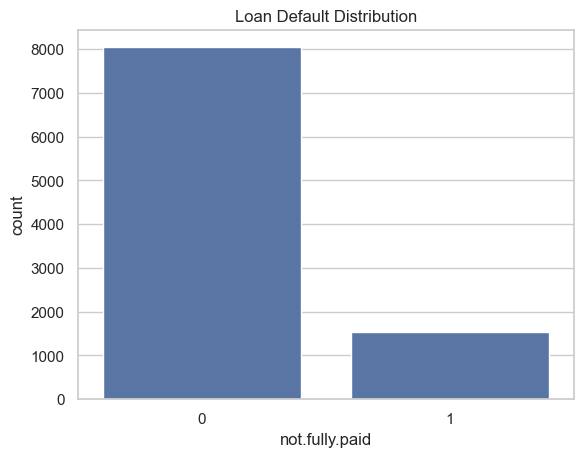

not.fully.paid
0    0.839946
1    0.160054
Name: proportion, dtype: float64


In [18]:
sns.countplot(x='not.fully.paid', data=loan)
plt.title('Loan Default Distribution')
plt.show()

print(loan['not.fully.paid'].value_counts(normalize=True))

## 5. Exploratory Data Analysis (EDA)

- Analyze numeric features: distributions and relationship with target.
- Analyze categorical features (`purpose`) and their default rates.

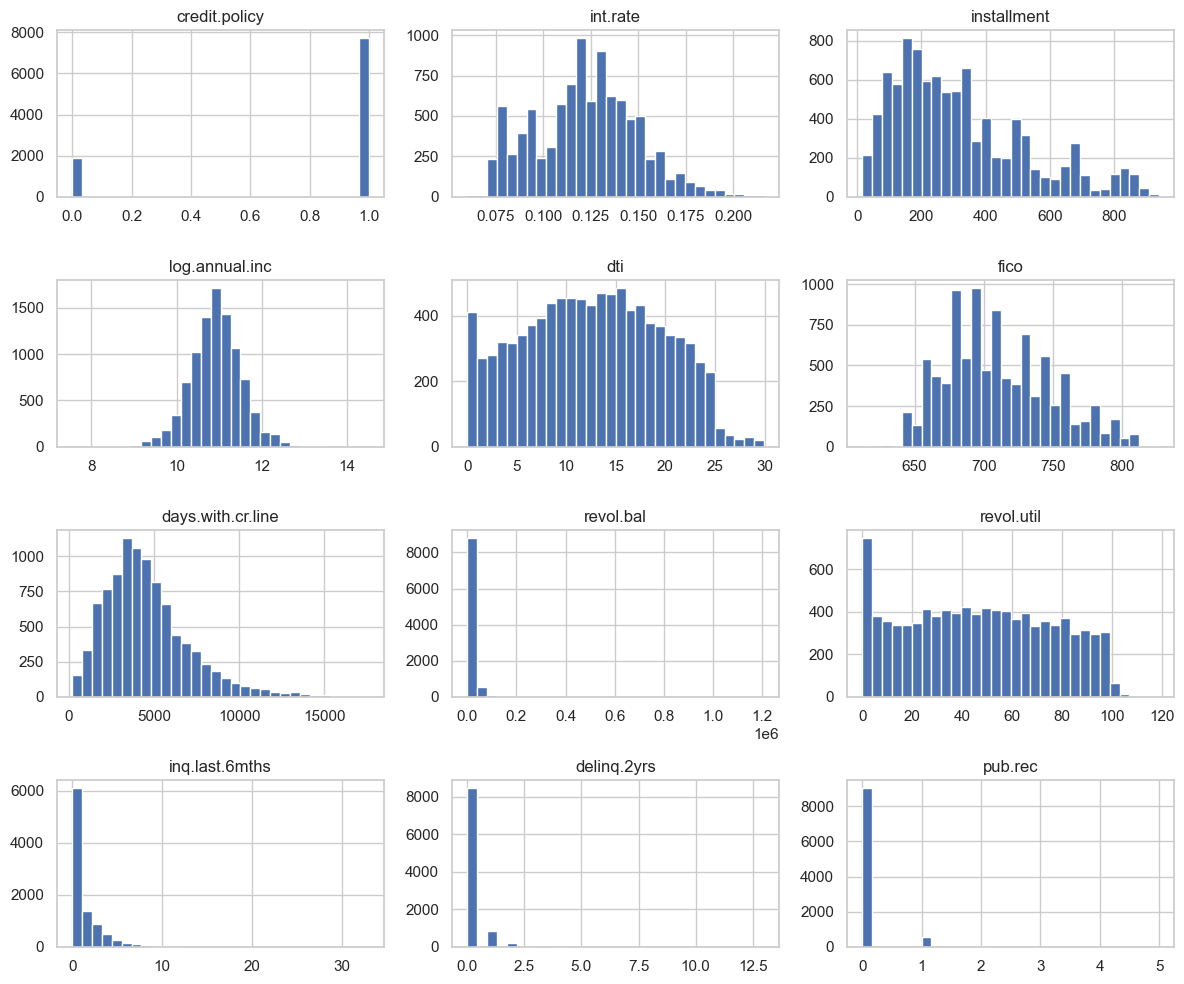

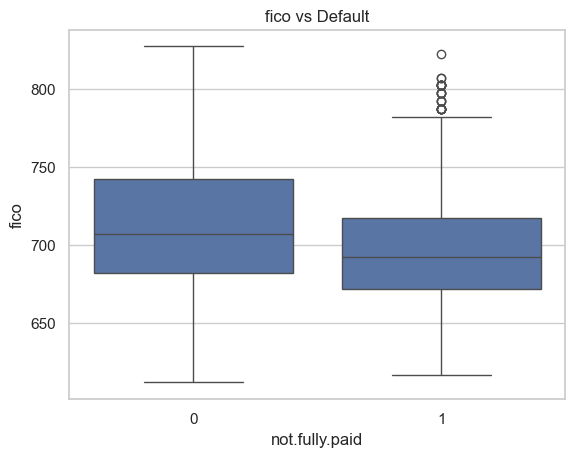

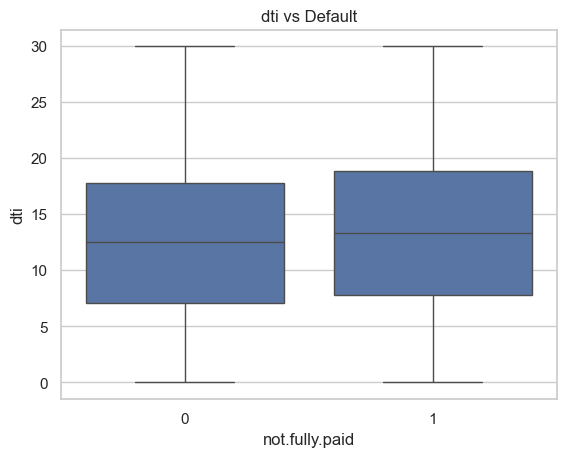

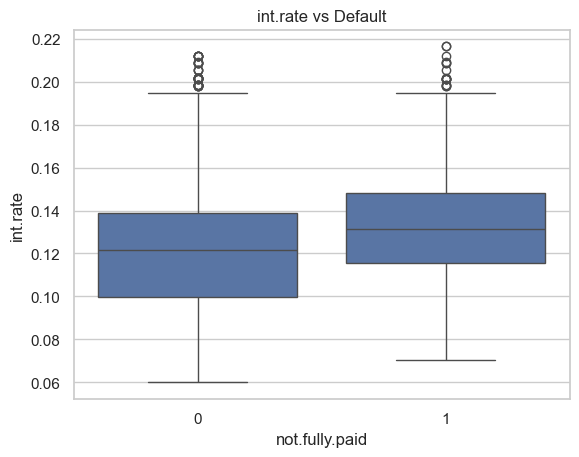

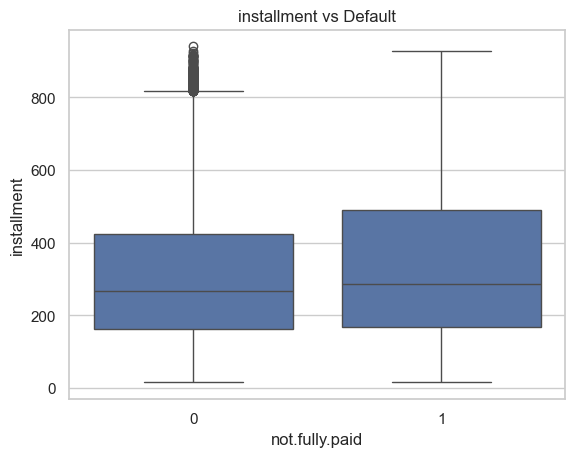

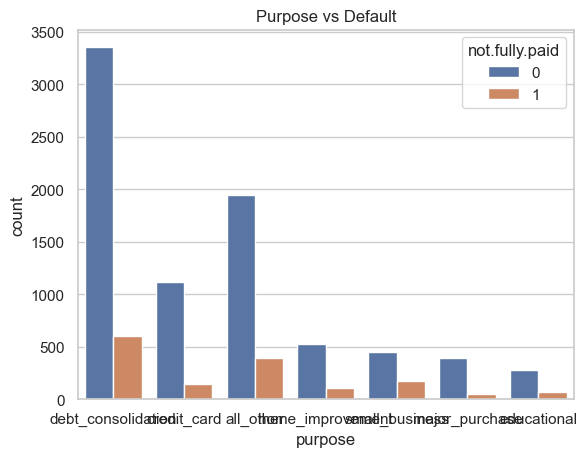

In [19]:
# Numeric features distribution
numeric_cols = loan.select_dtypes(include=['float64', 'int64']).columns.tolist()
numeric_cols.remove('not.fully.paid')

loan[numeric_cols].hist(figsize=(12,10), bins=30)
plt.tight_layout()
plt.show()

# Boxplots for key features vs target
key_features = ['fico', 'dti', 'int.rate', 'installment']
for col in key_features:
    sns.boxplot(x='not.fully.paid', y=col, data=loan)
    plt.title(f'{col} vs Default')
    plt.show()

# Categorical feature analysis
sns.countplot(x='purpose', hue='not.fully.paid', data=loan)
plt.title('Purpose vs Default')
plt.show()

## 6. Feature Transformation
Convert categorical variables to numeric using one-hot encoding.

In [20]:
loan = pd.get_dummies(loan, columns=['purpose'], prefix='purpose')

## 7. Correlation Analysis and Feature Selection
Remove highly correlated features to reduce multicollinearity.

In [21]:
exclude = ['not.fully.paid']
numeric_cols = [c for c in loan.columns if c not in exclude and loan[c].dtype in [np.float64, np.int64]]

corr = loan[numeric_cols + ['not.fully.paid']].corr().abs()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
to_drop = [column for column in upper.columns if any(upper[column] > 0.85)]
print("Dropped due to high correlation:", to_drop)

loan = loan.drop(columns=to_drop)

Dropped due to high correlation: []


## 8. Train-Test Split and Scaling
Split data into train, validation, and test sets. Scale numeric features.

In [22]:
X = loan.drop('not.fully.paid', axis=1)
y = loan['not.fully.paid']

# Split train/val/test
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.15, stratify=y, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.176, stratify=y_train_full, random_state=42)

# Scale numeric columns
scaler = StandardScaler()
numeric_cols = [c for c in X_train.columns if X_train[c].dtype in [np.float64, np.int64]]
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_val[numeric_cols] = scaler.transform(X_val[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

## 9. Build Deep Learning Model
Use Keras to build a fully connected model with dropout.

In [23]:
def build_model(input_dim):
    model = models.Sequential([
        layers.Dense(128, activation='relu', input_shape=(input_dim,)),
        layers.Dropout(0.3),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(32, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['AUC'])
    return model

model = build_model(X_train.shape[1])
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 128)            │         2,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,929 (50.50 KB)

 Trainable params: 12,929 (50.50 KB)

 Non-trainable params: 0 (0.00 B)

## 10. Train Model
Include class weights to handle imbalance. Use early stopping and learning rate reduction.

In [24]:
class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(zip(np.unique(y_train), class_weights))

early_stop = callbacks.EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)
reduce_lr = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=256,
    class_weight=class_weight_dict,
    callbacks=[early_stop, reduce_lr],
    verbose=2
)

Epoch 1/100
27/27 - 2s - 59ms/step - AUC: 0.5588 - loss: 0.6869 - val_AUC: 0.6950 - val_loss: 0.6629 - learning_rate: 0.0010
Epoch 2/100
27/27 - 0s - 8ms/step - AUC: 0.6195 - loss: 0.6729 - val_AUC: 0.6991 - val_loss: 0.6398 - learning_rate: 0.0010
Epoch 3/100
27/27 - 0s - 7ms/step - AUC: 0.6319 - loss: 0.6663 - val_AUC: 0.6986 - val_loss: 0.6270 - learning_rate: 0.0010
Epoch 4/100
27/27 - 0s - 9ms/step - AUC: 0.6480 - loss: 0.6570 - val_AUC: 0.6959 - val_loss: 0.6322 - learning_rate: 0.0010
Epoch 5/100
27/27 - 0s - 7ms/step - AUC: 0.6510 - loss: 0.6520 - val_AUC: 0.6946 - val_loss: 0.6303 - learning_rate: 0.0010
Epoch 6/100
27/27 - 0s - 7ms/step - AUC: 0.6641 - loss: 0.6517 - val_AUC: 0.6950 - val_loss: 0.6353 - learning_rate: 0.0010
Epoch 7/100
27/27 - 0s - 6ms/step - AUC: 0.6699 - loss: 0.6471 - val_AUC: 0.6951 - val_loss: 0.6333 - learning_rate: 0.0010
Epoch 8/100
27/27 - 0s - 11ms/step - AUC: 0.6706 - loss: 0.6472 - val_AUC: 0.6954 - val_loss: 0.6334 - learning_rate: 5.0000e-04
Ep

## 11. Plot Training Curves
Visualize loss and AUC over epochs to show training progress.

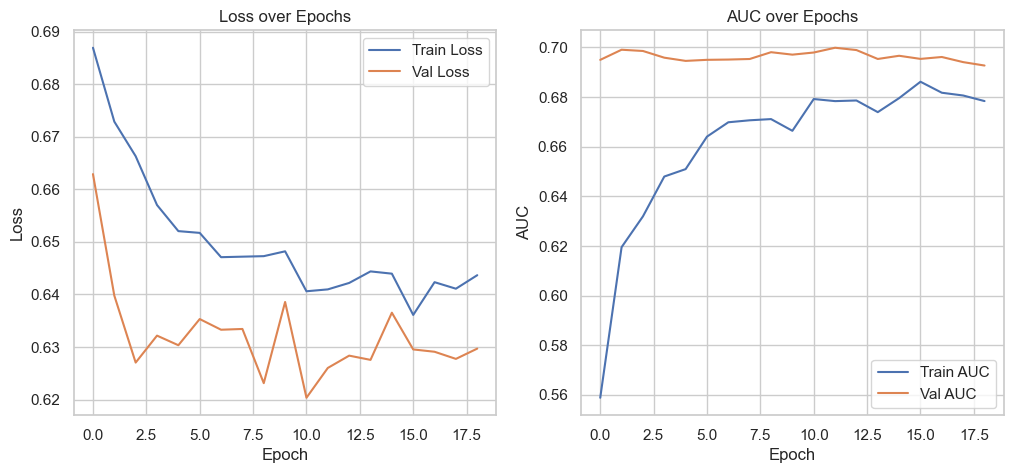

In [25]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['AUC'], label='Train AUC')
plt.plot(history.history['val_AUC'], label='Val AUC')
plt.title('AUC over Epochs')
plt.xlabel('Epoch')
plt.ylabel('AUC')
plt.legend()

plt.show()

## 12. Evaluate Model
Use ROC AUC, PR AUC, classification report, confusion matrix, ROC curve, and PR curve.

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
ROC AUC: 0.7046107849140881
PR AUC: 0.3071576208002623
              precision    recall  f1-score   support

           0       0.91      0.66      0.77      1207
           1       0.27      0.65      0.38       230

    accuracy                           0.66      1437
   macro avg       0.59      0.66      0.57      1437
weighted avg       0.81      0.66      0.70      1437

[[798 409]
 [ 80 150]]


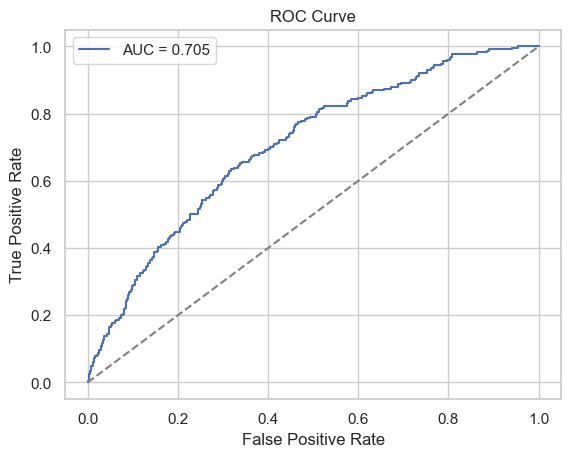

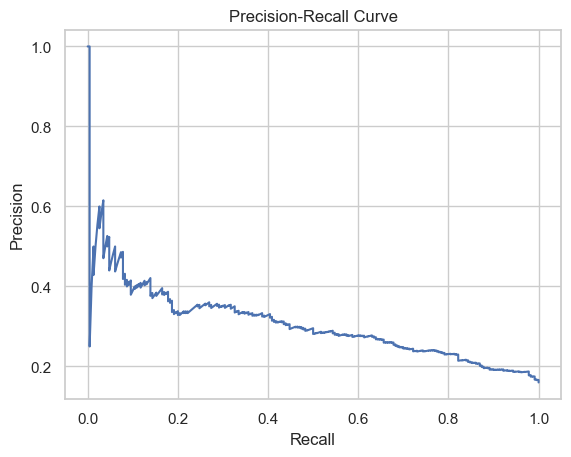

In [26]:
y_pred_proba = model.predict(X_test).ravel()
y_pred = (y_pred_proba >= 0.5).astype(int)

# Metrics
print('ROC AUC:', roc_auc_score(y_test, y_pred_proba))
print('PR AUC:', average_precision_score(y_test, y_pred_proba))
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
plt.plot(fpr, tpr, label=f'AUC = {roc_auc_score(y_test, y_pred_proba):.3f}')
plt.plot([0,1],[0,1],'--', color='gray')
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

# Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)
plt.plot(recall, precision)
plt.title('Precision-Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.show()

## 13. Predict on Bulk Input CSV
Prepare input, scale features, and make predictions.

In [27]:
input_df = pd.read_csv("Dataset/input.csv", header=None)
num_cols_input = [
    'credit.policy', 'int.rate', 'installment', 'log.annual.inc', 'dti', 'fico',
    'days.with.cr.line', 'revol.bal', 'revol.util',
    'inq.last.6mths', 'delinq.2yrs', 'pub.rec'
]
purpose_cols = [
    'purpose_all_other', 'purpose_credit_card', 'purpose_debt_consolidation',
    'purpose_educational', 'purpose_major_purchase', 'purpose_small_business'
]

input_df.columns = num_cols_input + purpose_cols

# Add missing columns
for col in X_train.columns:
    if col not in input_df.columns:
        input_df[col] = 0

input_df = input_df[X_train.columns]

# Scale numeric
input_df[numeric_cols] = scaler.transform(input_df[numeric_cols])

# Predict
proba = model.predict(input_df).ravel()
pred_class = (proba >= 0.5).astype(int)

output_df = pd.DataFrame({'default_probability': proba, 'predicted_default': pred_class})
output_df.to_csv(r"Dataset/predictions_output.csv", index=False)
output_df.head(10)

300/300 ━━━━━━━━━━━━━━━━━━━━ 0s 659us/step


,default_probability,predicted_default
0,0.458611,0
1,0.290779,0
2,0.504454,1
3,0.353635,0
4,0.369462,0
5,0.116437,0
6,0.512212,1
7,0.428071,0
8,0.337032,0
9,0.470991,0


In [30]:
output_df['predicted_default'].value_counts()

predicted_default
0    5906
1    3672
Name: count, dtype: int64

In [31]:
"Average predicted default probability:", output_df['default_probability'].mean()

('Average predicted default probability:', 0.44669735)